# MWE: a rapidly rotating star seen by CHARA, with `GravityDarkenedStar`

This notebook shows how to simulate and retrieve a gravity-darkened, rapidly rotating star from CHARA-like interferometry with drpangloss, and it explains the physics along the way. The model, `drpangloss.models.GravityDarkenedStar`, is **Shashank Dholakia's** JAX implementation of the Espinosa Lara and Rieutord (2011, A&A 533, A43; "ELR11") model of a rotating star, from his `jax-interferometry` code, which has been ported into drpangloss. All of the surface physics in this notebook is his work, and we are grateful to him for it. You should come away knowing what the model's parameters mean, what a rapid rotator looks like to an interferometer, and how to recover the star's size, spin rate, inclination and spin-axis direction from squared visibilities and closure phases with the same `fit` call that drpangloss uses for every other model.

A star that spins fast enough is no longer a sphere. Write $\omega = \Omega/\Omega_K$ for its angular velocity as a fraction of the Keplerian rate at which gravity and the centrifugal force balance at the equator, so that $\omega = 1$ is critical rotation. A rigidly rotating star takes the shape of a Roche spheroid, with the equatorial radius larger than the polar one by $R_\mathrm{eq}/R_\mathrm{pole} = 1 + \omega^2/2$, so that a star at $\omega = 0.92$ is about 42 percent wider than it is tall. Because the effective gravity is also weaker at the equator, where the centrifugal force opposes gravity, the equator is cooler and fainter than the poles, and this is the effect called gravity darkening. The classical law of von Zeipel says that the local temperature scales as $T \propto g^\beta$ with $\beta = 1/4$, but this over-predicts the contrast for fast rotators, and interferometric fits to stars such as Altair have found a smaller $\beta$. ELR11 avoids the free exponent altogether: they derive the flux from the requirement that it points opposite to the effective gravity, which fixes the temperature everywhere on the Roche surface once $\omega$ and the polar temperature are known.

For an interferometer this has three consequences, which this notebook will make visible in turn. The squared visibility $V^2$ shows the flattening, because the star is narrower along the spin axis, and so its visibility falls more slowly, and extends to longer baselines, in that direction. If the star is seen at an inclination below 90 degrees (0 is pole-on and 90 is equator-on), the hotter and brighter visible pole makes the image lopsided, and a lopsided image has non-zero closure phases, which also fix the position angle of the pole over the full 360 degrees where $V^2$ alone cannot tell North from South. Finally, the contrast between pole and equator is chromatic, stronger in the blue, so the model has a mode, switched on by giving the pole's temperature `t_pole`, in which every patch of the surface radiates as a black body at its own temperature. Below we build an Altair-like star, inspired by the CHARA/MIRC imaging of Monnier et al. (2007, Science 317, 342) but not an exact reproduction of it, with an equatorial diameter of 3.3 mas, $\omega = 0.92$, an inclination of 56 degrees and a pole at position angle 298 degrees, which is 62 degrees West of North, and a polar temperature of 8500 K. We draw the visible surface, with East to the left and North up.

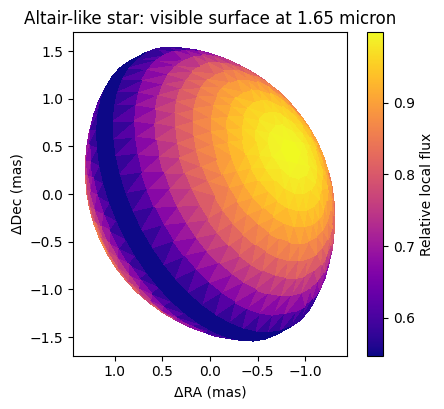

In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

from drpangloss.coverage import vlti_oidata
from drpangloss.fitting import fit
from drpangloss.inference import laplace_cov
from drpangloss.models import GravityDarkenedStar
from drpangloss.plotting import (
    plot_data_model_correlation,
    plot_model,
    plot_residual_map,
)

truth = GravityDarkenedStar(
    3.3, omega=0.92, inc=56.0, pa=298.0, t_pole=8500.0, n_lat=24
)
fig, ax = plt.subplots(figsize=(5, 4.2))
truth.plot_surface(ax=ax)
ax.set_title("Altair-like star: visible surface at 1.65 micron")
plt.show()

The bright patch is the visible pole, towards the upper right (North up, West to the right) because we gave it a position angle of 298 degrees, that is 62 degrees West of North, and the dark belt running across the star below it is the gravity-darkened equator, with the colour bar showing the local flux relative to its mean. Notice also that the outline is not a circle: the model has drawn the Roche spheroid projected on the sky. The surface is a mesh of 24 latitude rings, coarser than the model's default of 32, which keeps each visibility evaluation cheap and is the mesh we use for everything below, so the triangles are visible in the plot.

To observe it we need a set of baselines. CHARA is a six-telescope array on Mount Wilson, at latitude +34.224 degrees, with baselines up to about 330 m, and `vlti_oidata` builds simulated coverage for any list of telescope positions, so we simply give it CHARA's stations instead of the VLTI's. Each position below is the approximate (East, North) offset in metres from S1. Altair is at declination +8.87 degrees, and for the five hour angles we choose, spread over six hours around transit, the baselines trace arcs in the uv plane as the Earth turns. We take eight channels across the H band, from 1.50 to 1.74 microns, as for the MIRC-X combiner, and modest errors of 0.01 on $V^2$ and 0.75 degrees on the closure phases. We then fill the empty dataset with the observables of the truth plus seeded noise using `with_model`. To put the coverage in context we draw it, in units of megawavelengths ($u/\lambda$ and $v/\lambda$, with both signs because a visibility at $-\mathbf{u}$ is the conjugate of that at $+\mathbf{u}$), on top of the truth's visibility amplitude, with the star's image alongside for reference.

In [2]:
chara = [  # (East, North) in metres relative to S1
    (0.0, 0.0),
    (-5.75, 33.58),
    (125.33, 305.93),
    (70.39, 269.72),
    (-175.07, 216.33),
    (-69.09, 199.34),
]
template = vlti_oidata(
    chara,
    declination_deg=8.87,
    latitude_deg=34.224,
    hour_angles_h=(-3.0, -1.5, 0.0, 1.5, 3.0),
    wavelengths_m=np.linspace(1.50e-6, 1.74e-6, 8),
    sigma_v2=0.01,
    sigma_cp_deg=0.75,
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
u, v = (
    np.asarray(data.u / data.wavel) / 1e6,
    np.asarray(data.v / data.wavel) / 1e6,
)
print(
    f"{data.vis.size} V2 and {data.phi.size} closure phases, 8 channels, max B/lambda = {np.hypot(u, v).max():.0f} Mlambda"
)

600 V2 and 800 closure phases, 8 channels, max B/lambda = 220 Mlambda


The printed line summarises the simulated dataset: 600 squared visibilities and 800 closure phases, from 15 baselines and 20 triangles at each of five hour angles, in eight channels, with the longest baselines reaching about 220 megawavelengths. To put this coverage in context we draw it on top of the truth's squared visibility, which we compute from the model itself, with `truth.model(u, v, wavel)`, on a regular grid in the uv plane at 1.65 microns. The function takes baselines in metres, so a grid point at spatial frequency $u/\lambda$ in megawavelengths is passed as $u = (u/\lambda)\,\lambda$. We plot $\log_{10} V^2$, clipped at $-3$, in units of megawavelengths with both signs, because a visibility at $-\mathbf{u}$ is the conjugate of that at $+\mathbf{u}$, and put the star's image alongside for reference.

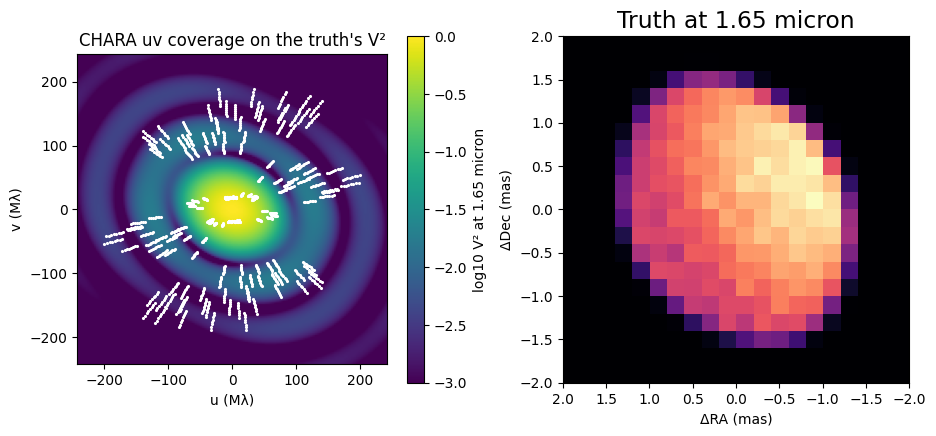

In [3]:
wavel0 = 1.65e-6
half = 1.1 * np.hypot(u, v).max()
g = np.linspace(-half, half, 181)
gu, gv = np.meshgrid(g, g)
vis0 = truth.model(
    gu.ravel() * 1e6 * wavel0, gv.ravel() * 1e6 * wavel0, wavel0
)
log_v2 = np.log10(np.abs(vis0).reshape(gu.shape) ** 2 + 1e-12)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4.5))
im = a0.imshow(
    log_v2,
    extent=[-half, half, -half, half],
    origin="lower",
    cmap="viridis",
    vmin=-3,
    vmax=0,
)
a0.plot(np.r_[u, -u], np.r_[v, -v], "w.", ms=2.5)
a0.set(
    xlabel="u (Mλ)",
    ylabel="v (Mλ)",
    title="CHARA uv coverage on the truth's V²",
)
fig.colorbar(im, ax=a0, label="log10 V² at 1.65 micron")
plot_model(truth, fov_mas=4.0, npix=20, ax=a1, title="Truth at 1.65 micron")
plt.show()

The map on the left shows $V^2$ of the truth, the squared modulus of the Fourier transform of the star, and it is not circularly symmetric: the lobes are narrower along the star's long axis, the direction in which the star is larger, and wider perpendicular to it, which is the flattening. The white dots, which are the baselines of all five hour angles in all eight channels, sample it on arcs that reach well past the first null. A 3.3 mas star is therefore resolved with several lobes by the longest baselines, which is what lets CHARA see its shape rather than just its size. In the next figure we plot the simulated observables themselves. On the left is $V^2$ against spatial frequency $B/\lambda$, coloured by the position angle of the baseline modulo 180 degrees. For a circular star all the colours would fall on one curve, because $V^2$ would depend only on the baseline length, and the spread between them at a given spatial frequency is the flattening: baselines along the spin axis, which sees a smaller star, have a visibility that falls more slowly. On the right are the closure phases, plotted against the highest spatial frequency among the three baselines of the triangle. A centrosymmetric star would have closure phases of exactly zero or 180 degrees, so the phases that depart from these are the signature of the bright pole, and they grow as the baselines resolve the star more and more.

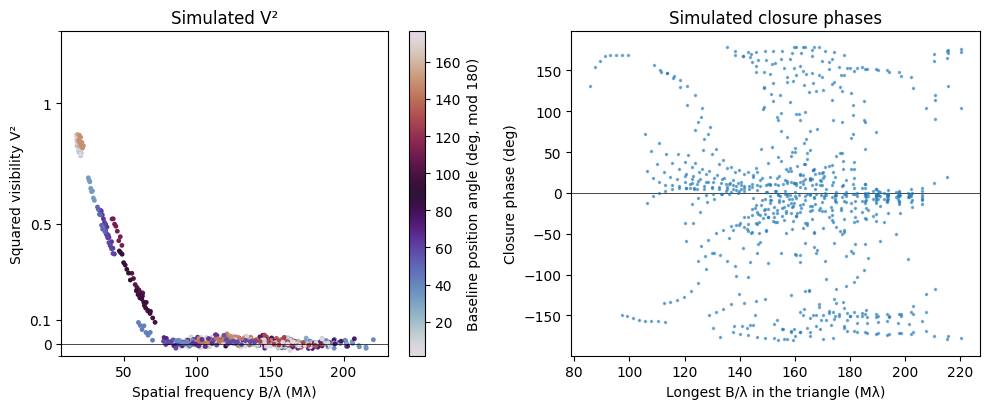

In [4]:
bl = np.hypot(u, v)
pa_bl = np.degrees(np.arctan2(u, v)) % 180
i1, i2, i3 = (np.asarray(i) for i in (data.i_cps1, data.i_cps2, data.i_cps3))
bl_cp = np.max([bl[i1], bl[i2], bl[i3]], axis=0)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 4.2))
sc = a0.scatter(bl, np.asarray(data.vis), c=pa_bl, s=6, cmap="twilight")
a0.axhline(0, color="k", lw=0.5)
a0.set(
    xlabel="Spatial frequency B/λ (Mλ)",
    ylabel="Squared visibility V²",
    yscale="symlog",
    ylim=(-0.05, 1.3),
    title="Simulated V²",
)
a0.set(yticks=[0, 0.1, 0.5, 1], yticklabels=["0", "0.1", "0.5", "1"])
fig.colorbar(sc, ax=a0, label="Baseline position angle (deg, mod 180)")
a1.errorbar(
    bl_cp,
    np.degrees(np.asarray(data.phi)),
    np.degrees(np.asarray(data.d_phi)),
    fmt=".",
    ms=3,
    lw=0.5,
    alpha=0.5,
)
a1.axhline(0, color="k", lw=0.5)
a1.set(
    xlabel="Longest B/λ in the triangle (Mλ)",
    ylabel="Closure phase (deg)",
    title="Simulated closure phases",
)
plt.tight_layout()
plt.show()

Now we try to recover the star. We call `fit`, exactly as for any other drpangloss model, with a Uniform prior on each of the four parameters we want, the equatorial diameter, the rotation rate, the inclination and the position angle of the pole over its full 360 degrees, and a deliberately wrong starting star, with a smaller diameter, a lower rotation rate, a lower inclination and the pole 48 degrees away from the truth. The polar temperature and reference wavelength are held fixed, since a single band with only a few channels cannot constrain the spectrum, and the model is built on a coarser mesh of 24 latitude rings to keep each evaluation cheap. The fit uses Levenberg–Marquardt on the whitened residuals of $V^2$ and the closure phases. We then use `laplace_cov` from `drpangloss.inference` to turn the curvature of the likelihood at the solution into a covariance matrix, whose diagonal gives the one-sigma uncertainties. The Laplace calculation is done in double precision, as the likelihood is extremely sharp. The table compares the truth with the fit, and the last line shows the correlations that the covariance contains.

In [5]:
priors = {
    "diam_eq": dist.Uniform(1.0, 8.0),
    "omega": dist.Uniform(0.0, 0.99),
    "inc": dist.Uniform(0.0, 90.0),
    "pa": dist.Uniform(0.0, 360.0),
}
start = GravityDarkenedStar(
    2.8, omega=0.5, inc=30.0, pa=250.0, t_pole=8500.0, n_lat=24
)
result = fit(start, priors, data)
names = list(priors)
with jax.enable_x64(True):
    best = np.array([float(result.values[k]) for k in names])
    cov = np.asarray(laplace_cov(best, names, data, start))
sig, corr = (
    np.sqrt(np.diag(cov)),
    cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov))),
)
print(f"{'':>8}{'truth':>10}{'start':>10}{'fit':>12}{'± sigma':>10}")
for i, k in enumerate(names):
    print(
        f"{k:>8}{float(getattr(truth, k)):10.3f}{float(getattr(start, k)):10.3f}{best[i]:12.4f}{sig[i]:10.4f}"
    )
print(
    f"chi2/N = {result.info['chi2_red']:.2f};  corr(omega, inc) = {corr[1, 2]:+.2f}, corr(diam_eq, omega) = {corr[0, 1]:+.2f}"
)

             truth     start         fit   ± sigma
 diam_eq     3.300     2.800      3.2997    0.0002
   omega     0.920     0.500      0.9200    0.0002
     inc    56.000    30.000     55.9434    0.0389
      pa   298.000   250.000    298.0110    0.0087
chi2/N = 1.05;  corr(omega, inc) = -0.46, corr(diam_eq, omega) = +0.73


The fit should land close to the truth, with a reduced chi-squared near one. The formal uncertainties are tiny, a small fraction of a microarcsecond on the diameter, because baselines that reach three lobes into the visibility function are extraordinarily sensitive to the size and shape. Note that we fit with the same mesh that generated the data, so there is no model error in this test, and we should not read the sigmas as the accuracy of a real measurement, where limb darkening, calibration errors and bandwidth smearing, none of which are in the model, would dominate, and where a finer or different mesh would shift the answer by many sigma. To check the fit across the whole dynamic range we use `plot_data_model_correlation`, which plots the model against the data with the data errors as horizontal bars and a one-to-one line, for the squared visibilities on the left and the closure phases, in radians, on the right. The function expects a summary with a mean and a spread for each prediction, and since our fit is a single point estimate we pass its predictions with zero spread. Points on the line are well fitted, and the scatter about it should be of the size of the error bars.

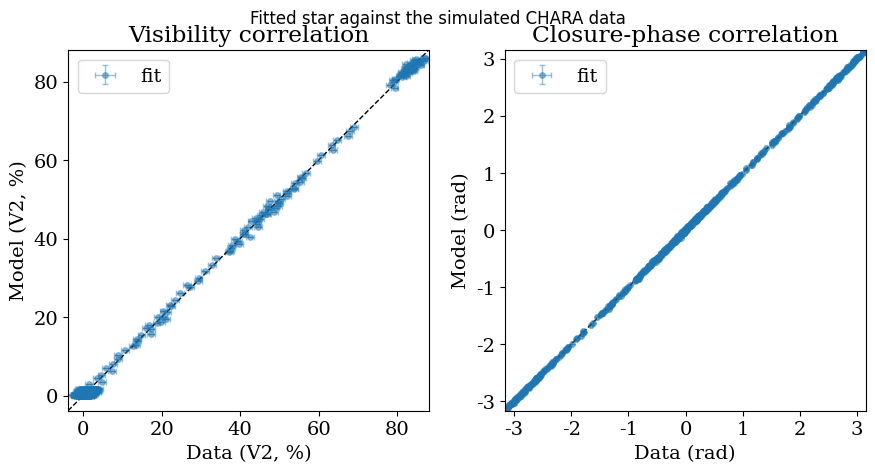

In [6]:
n_vis = data.vis.size
prediction = data.model(result.model)
summary = {
    "fit": {
        "vis_mean": prediction[:n_vis],
        "vis_std": 0 * prediction[:n_vis],
        "phi_mean": prediction[n_vis:],
        "phi_std": 0 * prediction[n_vis:],
    }
}
fig, _ = plot_data_model_correlation(
    data, summary, figsize=(9, 4.5), phase_title="Closure-phase correlation"
)
fig.suptitle("Fitted star against the simulated CHARA data", y=1.02)
plt.show()

Finally we compare the images. We render the truth and the fitted star on the same grid, a field of view of 4 mas on 20 pixels, which is 0.2 mas per pixel. We keep this grid modest because `render` places each surface triangle on the nearest pixel, so on a finer grid than the mesh the image would look speckled. Both images are normalised to unit total flux, so the residual map on the right, drawn by `plot_residual_map` on a symmetric diverging colour scale, shows plain residuals (fit minus truth, as a fraction of the total flux) and not z-scores, since an image has no per-pixel uncertainty here. We should expect it to be very small.

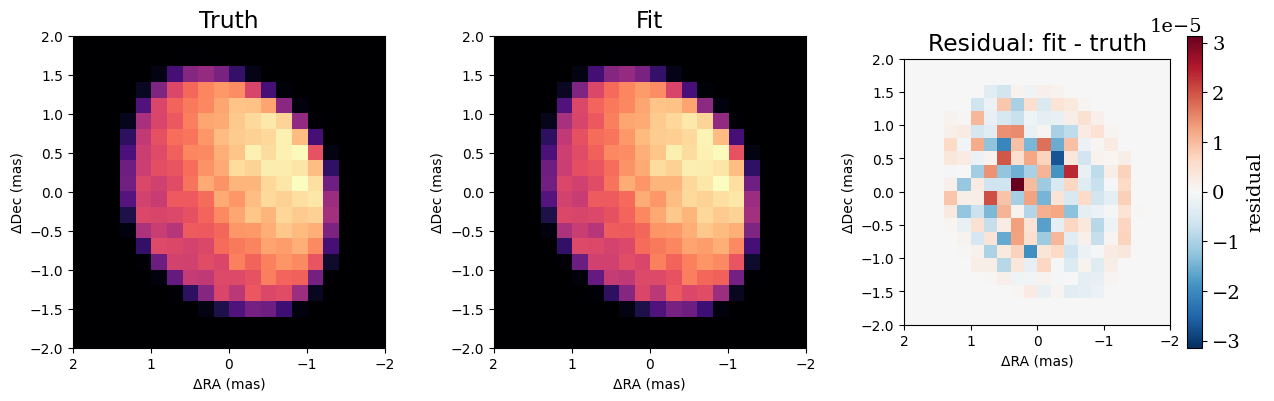

In [7]:
fov, npix = 4.0, 20
fit_star = result.model
residual = np.asarray(fit_star.render(npix, fov)) - np.asarray(
    truth.render(npix, fov)
)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_model(truth, fov, npix, ax=axes[0], title="Truth")
plot_model(fit_star, fov, npix, ax=axes[1], title="Fit")
plot_residual_map(residual, fov, ax=axes[2], title="Residual: fit - truth")
plt.tight_layout()
plt.show()

**Summary.** From 600 squared visibilities and 800 closure phases in eight H-band channels, taken at five hour angles on a CHARA-like six-telescope array, `fit` recovered the Altair-like star's equatorial diameter, rotation rate, inclination and pole position angle from a poor starting guess, and the image of the fit matches the truth. The squared visibilities constrain the size and the flattening, and the closure phases, which exist only because the hot pole makes the star lopsided, fix the position angle of the pole over 360 degrees and help to separate the inclination from the rotation rate. These two parameters are the ones that remain correlated: flattening is set by $\omega$ and the projected flattening by $\omega$ and the inclination together, so a lower-resolution observation, with shorter baselines or fewer resolved lobes, would measure only the combination of the two, and the printed correlations show the beginnings of this even with these long baselines. The result is also only as good as its assumptions: there is no limb darkening, no bandwidth smearing and no fitted temperature here, and the real Altair has all of these.

To go further, look at the docstring of `GravityDarkenedStar`, in particular its chromatic mode, in which `t_pole` and `wavel0` make the contrast depend on wavelength and let the star supply its own spectrum to a `System` that includes a companion, and at the grey mode, which is Shashank's original model without a temperature. The re-analysis of Shashank's real CHARA/PAVO data with drpangloss, in the directory `examples/elr_pavo/`, is in progress. Reference: Espinosa Lara, F. and Rieutord, M. (2011), A&A 533, A43; Monnier, J. D. et al. (2007), Science 317, 342.